# 冬小麦产量预测 — 多源数据消融实验 (RF + LOYO)

**实验设计**
- 特征分 3 组：Static（土壤） / Meteorology（气象） / RS（遥感） / All（全组合）
- 阶段累积：P1 → P2 → P3 → P4
- 划分方式：Leave-One-Year-Out (LOYO)
- 模型：RandomForestRegressor（统一参数，不调参）

**评价指标**：R², RMSE, MAE, MAPE, RRMSE, d_index

  冬小麦产量预测 多源数据消融实验 (RF + LOYO)
[INFO] 加载数据: P4_Cleaned_Dataset.csv
[INFO] 目标缺失: 删 0 行, 剩余 119385 行
[INFO] 年份: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]  (6 折 LOYO)

──────────────────────────────────────────────────
[STAGE] P1  |  [GROUP] Static  |  特征数: 3
  特征: ['Clay', 'SOC', 'Sand']
  [1/96] LOYO test_year=2016 ... R²=0.049, RMSE=925.950, MAPE=10.4%
  [2/96] LOYO test_year=2017 ... R²=0.206, RMSE=863.100, MAPE=10.9%
  [3/96] LOYO test_year=2018 ... R²=0.144, RMSE=876.675, MAPE=11.9%
  [4/96] LOYO test_year=2019 ... R²=0.191, RMSE=870.449, MAPE=11.4%
  [5/96] LOYO test_year=2020 ... R²=0.147, RMSE=724.552, MAPE=9.9%
  [6/96] LOYO test_year=2021 ... R²=0.267, RMSE=761.938, MAPE=10.5%
  >>> 多年平均: R²=0.167, RMSE=837.111, MAE=616.346, MAPE=10.8%, RRMSE=13.6%, d_index=0.612

──────────────────────────────────────────────────
[STAGE] P1  |  [GROUP] Meteorology  |  特征数: 16
  特征: ['Cum_FDD_P1', 'Cum_PPT_P1', 'Cum_VPD_P1', 'P1_Decoupling_

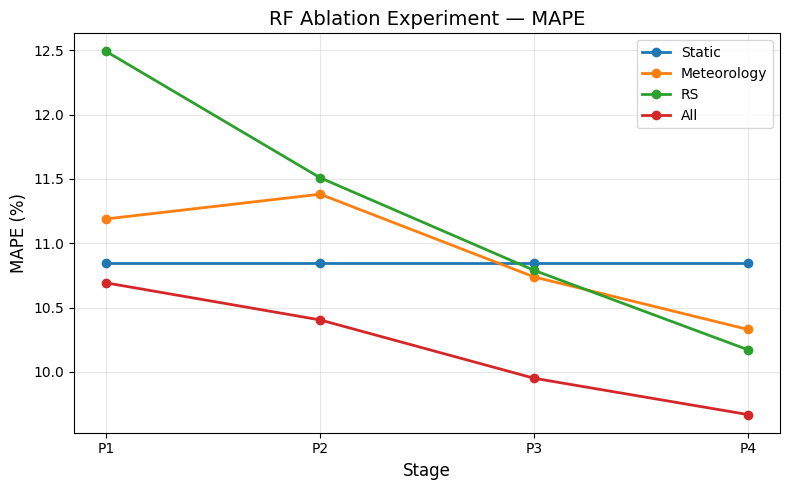

[INFO] 图表已保存: ../results_消融实验\rf_ablation_p1_p4_mape.png


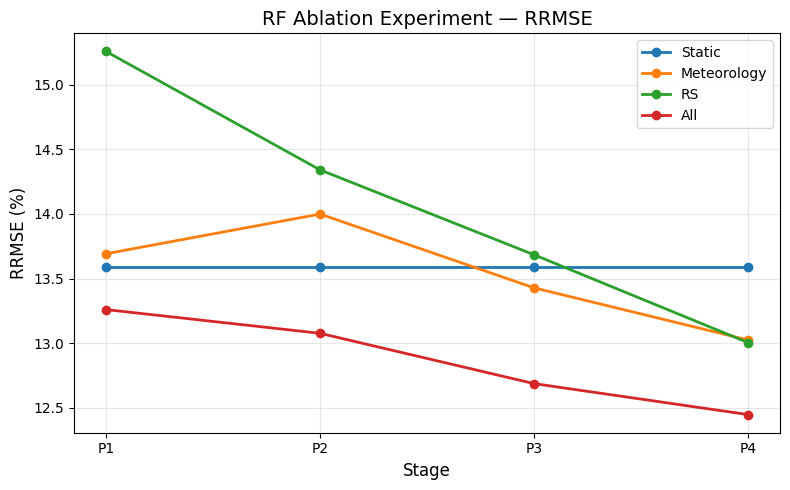

[INFO] 图表已保存: ../results_消融实验\rf_ablation_p1_p4_rrmse.png

  消融实验完成!


In [1]:
# ======================== 消融实验全部代码 ========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

# ======================== 1. 配置 ========================
DATA_PATH   = 'P4_Cleaned_Dataset.csv'
TARGET_COL  = 'yield'
OUTPUT_DIR  = '../results_消融实验'

NON_FEATURE_COLS = ['Year', 'Zone', 'latitude', 'longitude', TARGET_COL]

STAGES = [
    ('P1', ['P1']),
    ('P2', ['P1', 'P2']),
    ('P3', ['P1', 'P2', 'P3']),
    ('P4', ['P1', 'P2', 'P3', 'P4']),
]

RF_PARAMS = dict(n_estimators=300, random_state=42, n_jobs=-1,
                 max_features='sqrt', min_samples_leaf=1)

# ======================== 2. 特征分组关键词 ========================
STATIC_KEYWORDS = ['Sand', 'Clay', 'SOC']

METEOROLOGY_KEYWORDS = [
    'Tmean', 'PPT', 'SM', 'GDD', 'FDD', 'VPD', 'VPD_max',
    'WUE', 'Hydrothermal_Balance', 'Thermal_Efficiency',
    'Drought_Vulnerability', 'Decoupling_Stress', 'Fertility_Vigor',
    'Delta_SM',
]

RS_KEYWORDS = [
    'NDVI', 'NDVI_max', 'NDWI', 'NIRv',
    'EVI', 'EVI_max',
    'Delta_NDVI', 'Delta_NDWI',
]

# ======================== 3. 辅助函数 ========================
def load_data(path):
    print(f'[INFO] 加载数据: {path}')
    df = pd.read_csv(path)
    df.replace(-9999, np.nan, inplace=True)
    before = len(df)
    df = df.dropna(subset=[TARGET_COL])
    print(f'[INFO] 目标缺失: 删 {before - len(df)} 行, 剩余 {len(df)} 行')
    return df


def get_feature_columns(df, stage_prefixes, feature_group):
    """根据阶段前缀和分组返回特征列名"""
    all_cols = df.columns.tolist()
    result = []
    for col in all_cols:
        if col in NON_FEATURE_COLS:
            continue
        # --- Static ---
        if feature_group in ('Static', 'All'):
            if not any(col.startswith(p + '_') or col.startswith('Cum_') or col.startswith('Delta_')
                       for p in ['P1', 'P2', 'P3', 'P4']):
                for kw in STATIC_KEYWORDS:
                    if col == kw and col not in result:
                        result.append(col)
                        break
        # --- Meteorology ---
        if feature_group in ('Meteorology', 'All'):
            for prefix in stage_prefixes:
                for kw in METEOROLOGY_KEYWORDS:
                    expected = f'{prefix}_{kw}'
                    if col == expected and col not in result:
                        result.append(col)
                        break
                for cum_kw in ['Cum_PPT', 'Cum_FDD', 'Cum_VPD']:
                    expected_cum = f'{cum_kw}_{prefix}'
                    if col == expected_cum and col not in result:
                        result.append(col)
                        break
                if col == f'Delta_SM_{prefix}' and col not in result:
                    result.append(col)
        # --- RS ---
        if feature_group in ('RS', 'All'):
            for prefix in stage_prefixes:
                for kw in RS_KEYWORDS:
                    expected = f'{prefix}_{kw}'
                    if col == expected and col not in result:
                        result.append(col)
                        break
                if col in (f'Delta_NDVI_{prefix}', f'Delta_NDWI_{prefix}') and col not in result:
                    result.append(col)
    return sorted(set(result))


def split_loyo(df, test_year):
    train_df = df[df['Year'] != test_year].copy()
    test_df  = df[df['Year'] == test_year].copy()
    X_train = train_df.drop(columns=NON_FEATURE_COLS, errors='ignore')
    y_train = train_df[TARGET_COL].values
    X_test  = test_df.drop(columns=NON_FEATURE_COLS, errors='ignore')
    y_test  = test_df[TARGET_COL].values
    # 删除全 NaN 行
    X_train = X_train.dropna(axis=0)
    y_train = train_df.loc[X_train.index, TARGET_COL].values
    X_test  = X_test.dropna(axis=0)
    y_test  = test_df.loc[X_test.index, TARGET_COL].values
    return X_train, y_train, X_test, y_test


def evaluate_metrics(y_true, y_pred):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    if len(y_true) == 0:
        return {k: np.nan for k in ['R2', 'RMSE', 'MAE', 'MAPE', 'RRMSE', 'd_index']}
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    rrmse = rmse / np.mean(y_true) * 100
    mean_obs = np.mean(y_true)
    num = np.sum((y_pred - y_true) ** 2)
    den = np.sum((np.abs(y_pred - mean_obs) + np.abs(y_true - mean_obs)) ** 2)
    d_index = 1.0 if den == 0 else 1.0 - num / den
    return dict(R2=r2, RMSE=rmse, MAE=mae, MAPE=mape, RRMSE=rrmse, d_index=d_index)


def run_single_exp(X_train, y_train, X_test, y_test, feature_cols):
    available = [c for c in feature_cols if c in X_train.columns]
    if len(available) == 0:
        raise ValueError(f'无可用特征!')
    X_tr = X_train[available].copy()
    X_te = X_test[available].copy()
    X_tr = X_tr.fillna(X_tr.median())
    X_te = X_te.fillna(X_tr.median())
    rf = RandomForestRegressor(**RF_PARAMS)
    rf.fit(X_tr, y_train)
    y_pred = rf.predict(X_te)
    metrics = evaluate_metrics(y_test, y_pred)
    metrics['n_features'] = len(available)
    metrics['used_features'] = available
    return metrics


# ======================== 4. 主实验 ========================
print('=' * 60)
print('  冬小麦产量预测 多源数据消融实验 (RF + LOYO)')
print('=' * 60)

os.makedirs(OUTPUT_DIR, exist_ok=True)
df = load_data(DATA_PATH)

years = sorted(df['Year'].dropna().unique().astype(int))
print(f'[INFO] 年份: {years}  ({len(years)} 折 LOYO)')

all_results = []
all_features = {}
total_exps = len(STAGES) * 4 * len(years)
exp_count = 0

for stage_label, stage_prefixes in STAGES:
    for group in ['Static', 'Meteorology', 'RS', 'All']:
        feat_cols = get_feature_columns(df, stage_prefixes, group)
        print('\n' + '─' * 50)
        print(f'[STAGE] {stage_label}  |  [GROUP] {group}  |  特征数: {len(feat_cols)}')
        if len(feat_cols) > 0:
            print(f'  特征: {feat_cols[:10]}{"..." if len(feat_cols) > 10 else ""}')
        all_features[f'{stage_label}_{group}'] = feat_cols

        yearly = {k: [] for k in ['R2', 'RMSE', 'MAE', 'MAPE', 'RRMSE', 'd_index']}

        for test_year in years:
            exp_count += 1
            print(f'  [{exp_count}/{total_exps}] LOYO test_year={test_year} ...', end=' ')
            try:
                X_train, y_train, X_test, y_test = split_loyo(df, test_year)
                if len(y_test) == 0:
                    print('无测试样本, 跳过')
                    continue
                m = run_single_exp(X_train, y_train, X_test, y_test, feat_cols)
                for k in yearly:
                    yearly[k].append(m[k])
                print(f"R²={m['R2']:.3f}, RMSE={m['RMSE']:.3f}, MAPE={m['MAPE']:.1f}%")
            except Exception as e:
                print(f'错误: {e}')

        # 多年平均
        summary = dict(stage=stage_label, feature_group=group,
                       n_features=len(feat_cols), n_years=len(yearly['R2']))
        for k in yearly:
            vals = [v for v in yearly[k] if not np.isnan(v)]
            summary[k] = np.mean(vals) if vals else np.nan
        all_results.append(summary)
        print(f"  >>> 多年平均: R²={summary['R2']:.3f}, RMSE={summary['RMSE']:.3f}, "
              f"MAE={summary['MAE']:.3f}, MAPE={summary['MAPE']:.1f}%, "
              f"RRMSE={summary['RRMSE']:.1f}%, d_index={summary['d_index']:.3f}")

# ======================== 5. 保存结果 ========================
results_df = pd.DataFrame(all_results)
csv_path = os.path.join(OUTPUT_DIR, 'rf_ablation_p1_p4_metrics.csv')
results_df.to_csv(csv_path, index=False)
print(f'\n[INFO] 结果表已保存: {csv_path}')
print(results_df.to_string())

json_path = os.path.join(OUTPUT_DIR, 'rf_ablation_p1_p4_features.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(all_features, f, indent=2, ensure_ascii=False)
print(f'[INFO] 特征清单已保存: {json_path}')

# ======================== 6. 绘图 ========================
for metric in ['MAPE', 'RRMSE']:
    fig, ax = plt.subplots(figsize=(8, 5))
    for group in ['Static', 'Meteorology', 'RS', 'All']:
        sub = results_df[results_df['feature_group'] == group].sort_values('stage')
        ax.plot(sub['stage'], sub[metric], marker='o', label=group, linewidth=2)
    ax.set_xlabel('Stage', fontsize=12)
    ax.set_ylabel(f'{metric} (%)', fontsize=12)
    ax.set_title(f'RF Ablation Experiment — {metric}', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fname = os.path.join(OUTPUT_DIR, f'rf_ablation_p1_p4_{metric.lower()}.png')
    fig.savefig(fname, dpi=150)
    plt.show()
    print(f'[INFO] 图表已保存: {fname}')

print('\n' + '=' * 60)
print('  消融实验完成!')
print('=' * 60)